In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout,
    Input, AdditiveAttention, Concatenate
)




In [2]:
# ============================================================
# BLOCK 2: Load and preprocess IMDB dataset
# Task: Binary sentiment classification
# ============================================================

VOCAB_SIZE = 10000
MAX_LEN = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

# Use smaller subset so training is fast in Colab
x_train = x_train[:10000]
y_train = y_train[:10000]
x_test = x_test[:3000]
y_test = y_test[:3000]

x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding="post", truncating="post")
x_test = pad_sequences(x_test, maxlen=MAX_LEN, padding="post", truncating="post")

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training shape: (10000, 200)
Testing shape: (3000, 200)


In [3]:
# ============================================================
# BLOCK 3: Function to build RNN / LSTM / GRU models
# ============================================================

def build_model(model_type):
    model = Sequential()
    model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=MAX_LEN))

    if model_type == "RNN":
        model.add(SimpleRNN(64))
    elif model_type == "LSTM":
        model.add(LSTM(64))
    elif model_type == "GRU":
        model.add(GRU(64))

    model.add(Dropout(0.4))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [4]:
# ============================================================
# BLOCK 4: Train and compare RNN, LSTM, GRU
# ============================================================

model_types = ["RNN", "LSTM", "GRU"]
histories = {}
results = []

for model_type in model_types:
    print("\nTraining", model_type)

    model = build_model(model_type)

    history = model.fit(
        x_train,
        y_train,
        epochs=3,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    histories[model_type] = history
    results.append({
        "Model": model_type,
        "Test Accuracy": test_acc,
        "Test Loss": test_loss
    })

results_df = pd.DataFrame(results)
results_df



Training RNN
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.4989 - loss: 0.7030 - val_accuracy: 0.5100 - val_loss: 0.6938
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.5871 - loss: 0.6697 - val_accuracy: 0.4765 - val_loss: 0.7283
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.6641 - loss: 0.5971 - val_accuracy: 0.5165 - val_loss: 0.7281

Training LSTM
Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - accuracy: 0.5129 - loss: 0.6933 - val_accuracy: 0.5160 - val_loss: 0.6918
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.5602 - loss: 0.6783 - val_accuracy: 0.6165 - val_loss: 0.6585
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - accuracy: 0.6152 - loss: 0.6284 - val_accuracy: 0.6100 - val_loss: 0.6409

Training GRU
Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 125ms/step - accuracy: 0.5058 - loss: 0.6938 - val_accuracy: 0.5080 - val_loss: 0.6923
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.5529 - los

,Model,Test Accuracy,Test Loss
0,RNN,0.496333,0.733172
1,LSTM,0.579667,0.651666
2,GRU,0.576000,0.690169


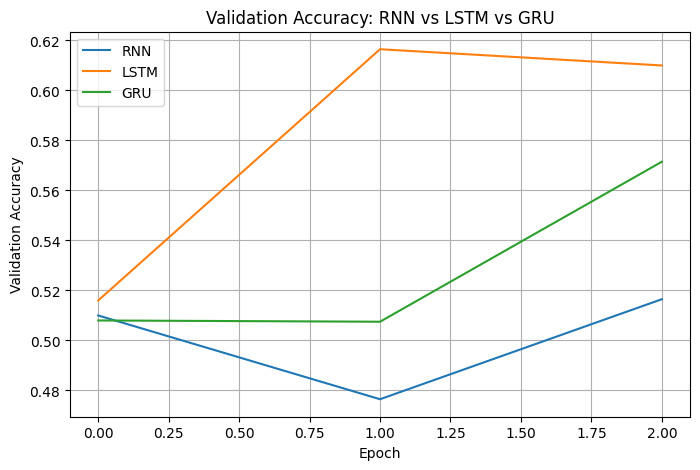

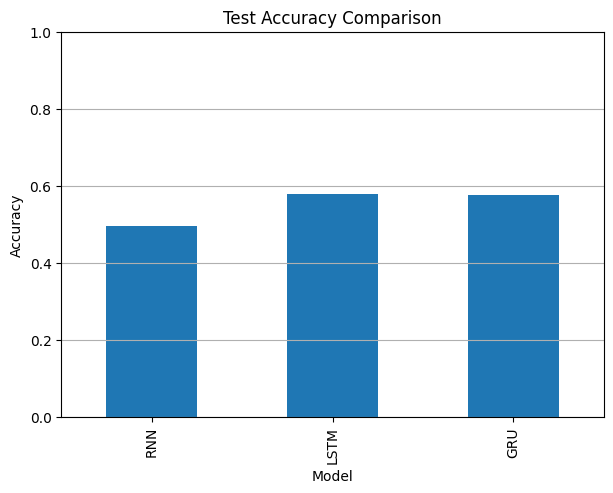

In [5]:
# ============================================================
# BLOCK 5: Plot model accuracy comparison
# ============================================================

plt.figure(figsize=(8, 5))

for model_type in model_types:
    plt.plot(
        histories[model_type].history["val_accuracy"],
        label=model_type
    )

plt.title("Validation Accuracy: RNN vs LSTM vs GRU")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

results_df.plot(
    x="Model",
    y="Test Accuracy",
    kind="bar",
    legend=False,
    figsize=(7, 5),
    title="Test Accuracy Comparison"
)

plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()


